In [1]:
import os
os.chdir("..")

import torch
from PIL import Image
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

from src.dataset.test_dataset import AIRecognitionDataset
from src.models.model_api import OpenSourceModel, HuggingFaceModel, APIProvider


In [2]:
load_dotenv()

True

In [16]:
# load subset
from torch import utils
from torch.utils.data import Subset
import random

def load_dataset(n_samples: int = 100) -> Subset:
    dataset = AIRecognitionDataset()
    all_indices = list(range(len(dataset)))
    random_indices = random.sample(all_indices, n_samples)
    subset = Subset(dataset, random_indices)

    print(f"Loaded {len(subset)} random samples.")
    img_path, label = subset[0]
    print(img_path, label)
    img = Image.open(img_path).convert('RGB')
    plt.imshow(img)
    plt.title(f"[EXAMPLE IMAGE] label: {label}")
    plt.axis('off')
    plt.show()
    
    return subset


In [ ]:
from src.models.api_providers import HiveAPIProvider, SightengineAPIProvider

def test_api_providers(dataset):
    local_models = [HiveAPIProvider(), SightengineAPIProvider()]

    test_len = len(dataset)
    for x in tqdm(dataset, desc="evaluation in progress...", total=test_len):
        img_path, label = x
        
        for model in local_models:
            print(f"RESULT FROM {model.__class__.__name__}")
            result = model.predict(img_path)
            print(f"result: {result}, true label: {label}")

In [18]:
from src.models.hf_models import (
    AIOrNotHfModel, SDXLDetectorHfModel, AIVSHumanImageDetectorHfModel, 
    HfModelOutput
)

def test_hf_models(dataset):
    local_models = [AIOrNotHfModel(), SDXLDetectorHfModel(), AIVSHumanImageDetectorHfModel()]
    
    test_len = len(dataset)
    for x in tqdm(dataset, desc="evaluation in progress...", total=len(dataset)):
        img_path, label = x
        img = Image.open(img_path).convert('RGB')
        plt.imshow(img)
        plt.title(f"Image {x}")
        plt.axis('off')
        plt.show()
        
        for model in local_models:
            print(f"RESULT FROM {model.__class__.__name__}")
            result = model.predict(img, with_probs=True)
            print(f"result: {result}, true label: {label}")

Loaded 10 random samples.
data/test/archive/fake-v2/12781.jpg fake


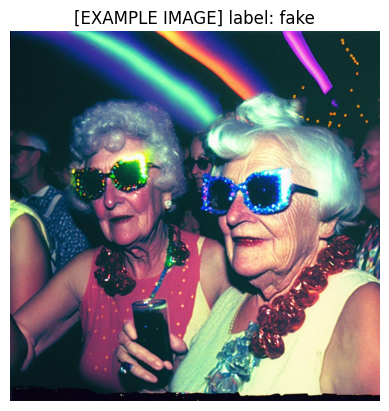

/Users/hxi/.pyenv/versions/3.10.4/lib/python3.10/site-packages/transformers/models/vit/feature_extraction_vit.py:30: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


[AIOrNotHfModel] Model initialization done.
[SDXLDetectorHfModel] Model initialization done.
Loading processor from: Ateeqq/ai-vs-human-image-detector
Loading model from: Ateeqq/ai-vs-human-image-detector
Model and processor loaded successfully.
[AIVSHumanImageDetectorHfModel] Model initialization done.


evaluation in progress...:   0%|          | 0/10 [00:00<?, ?it/s]

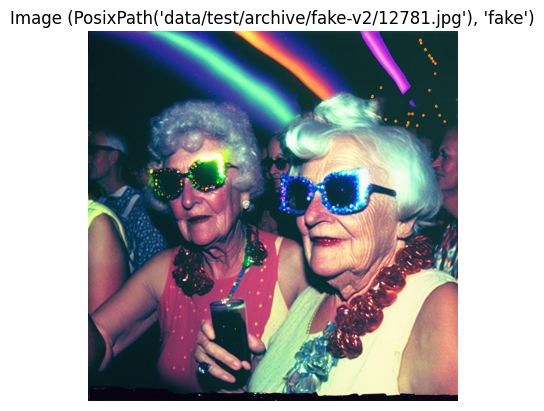

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.004359245765954256, 0.995640754699707], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='fake' probs=[3.417249558879121e-07, 0.9999996423721313], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  10%|█         | 1/10 [00:00<00:05,  1.80it/s]

result: label='fake' probs=[0.9989259839057922, 0.0010740356519818306], true label: fake


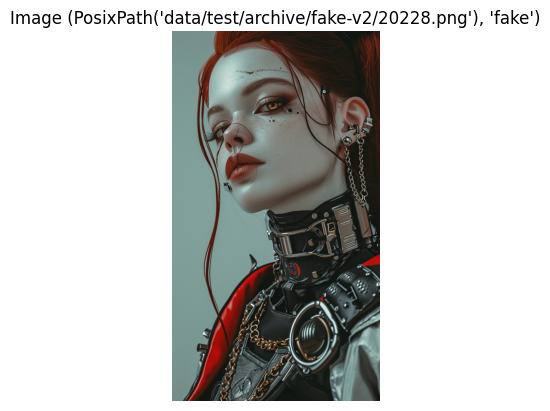

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.0012693185126408935, 0.9987307190895081], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='real' probs=[0.9996401071548462, 0.0003598949406296015], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  20%|██        | 2/10 [00:01<00:04,  1.71it/s]

result: label='fake' probs=[0.9999892711639404, 1.0694989214243833e-05], true label: fake


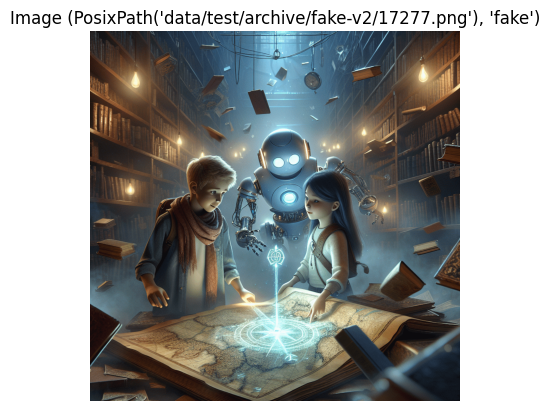

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.27680504322052, 0.7231950163841248], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='real' probs=[0.9989597797393799, 0.001040155882947147], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  30%|███       | 3/10 [00:01<00:03,  1.75it/s]

result: label='fake' probs=[0.9999995231628418, 5.331646661943523e-07], true label: fake


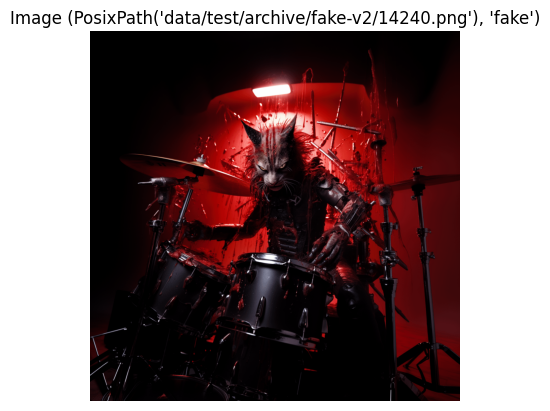

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.10828696191310883, 0.8917129635810852], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='real' probs=[0.9974000453948975, 0.002599917585030198], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  40%|████      | 4/10 [00:02<00:03,  1.78it/s]

result: label='fake' probs=[0.9996065497398376, 0.0003934818087145686], true label: fake


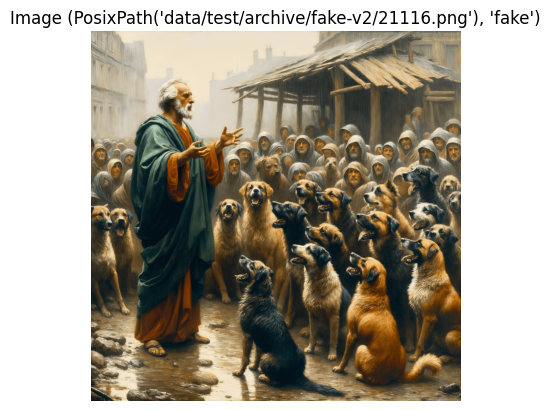

RESULT FROM AIOrNotHfModel
result: label='real' probs=[0.5744978785514832, 0.42550206184387207], true label: fake
RESULT FROM SDXLDetectorHfModel


evaluation in progress...:  50%|█████     | 5/10 [00:02<00:03,  1.62it/s]

result: label='real' probs=[0.9994944334030151, 0.0005055953515693545], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel
result: label='fake' probs=[0.999972939491272, 2.704460894165095e-05], true label: fake


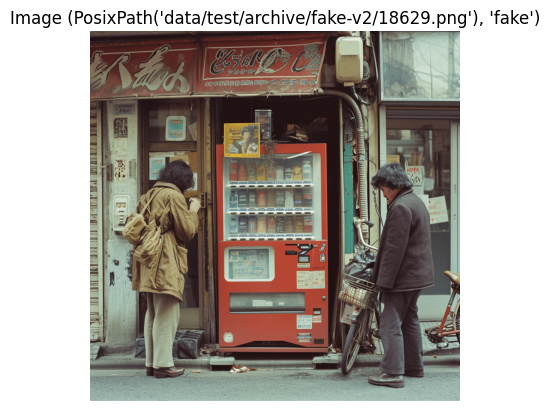

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.03562624007463455, 0.964373767375946], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='real' probs=[0.9983683228492737, 0.0016316513065248728], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  60%|██████    | 6/10 [00:03<00:02,  1.74it/s]

result: label='fake' probs=[0.9957868456840515, 0.004213194828480482], true label: fake


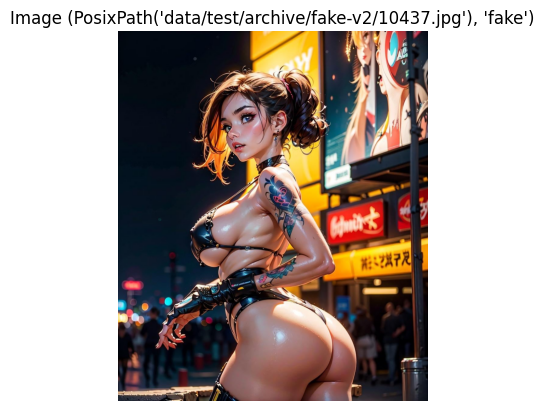

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.1940223127603531, 0.8059777021408081], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='fake' probs=[0.000512965430971235, 0.999487042427063], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  70%|███████   | 7/10 [00:03<00:01,  1.83it/s]

result: label='fake' probs=[0.9999978542327881, 2.184666527682566e-06], true label: fake


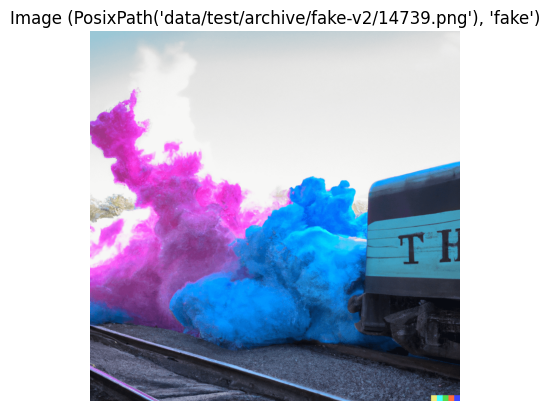

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.005103196948766708, 0.9948968291282654], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='real' probs=[0.9864522218704224, 0.013547778129577637], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  80%|████████  | 8/10 [00:04<00:01,  1.84it/s]

result: label='real' probs=[5.2787210734095424e-05, 0.999947190284729], true label: fake


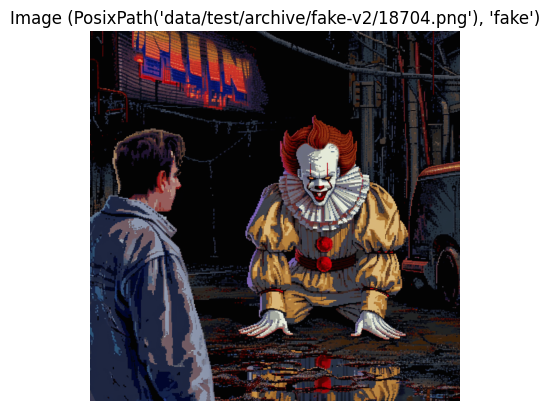

RESULT FROM AIOrNotHfModel
result: label='real' probs=[0.5933525562286377, 0.4066474139690399], true label: fake
RESULT FROM SDXLDetectorHfModel
result: label='fake' probs=[3.705149822508247e-07, 0.9999996423721313], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel


evaluation in progress...:  90%|█████████ | 9/10 [00:05<00:00,  1.85it/s]

result: label='real' probs=[0.0021796415094286203, 0.9978203773498535], true label: fake


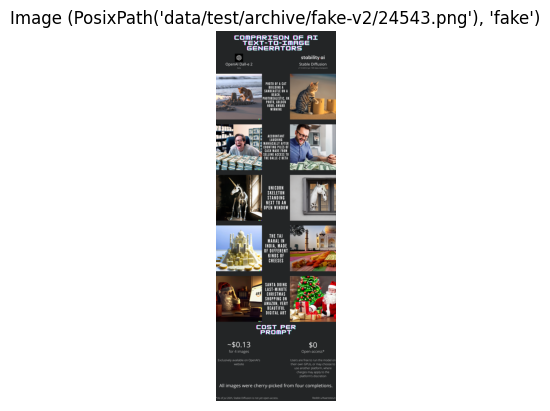

RESULT FROM AIOrNotHfModel
result: label='fake' probs=[0.07099909335374832, 0.9290009140968323], true label: fake
RESULT FROM SDXLDetectorHfModel


evaluation in progress...: 100%|██████████| 10/10 [00:06<00:00,  1.65it/s]

result: label='real' probs=[0.9838939309120178, 0.01610608585178852], true label: fake
RESULT FROM AIVSHumanImageDetectorHfModel
result: label='real' probs=[0.0012815698282793164, 0.9987185001373291], true label: fake


In [19]:
ds = load_dataset(n_samples=10)
test_hf_models(ds)

In [23]:
"""
    Thorough testing
"""
from collections import defaultdict
from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

from src.models.model_api import DiscriminatorModel


def evaluate(dataset: Subset, local_models: list[DiscriminatorModel]) -> None:
    # ------------------------- 1.  run inference -------------------------
    y_true          = defaultdict(list)   # model_name -> [0/1, ...]
    y_pred          = defaultdict(list)
    y_prob          = defaultdict(list)   # probability of class 1 (“fake”)
    inference_times = defaultdict(list)   # seconds

    label2idx = {"real": 0, "fake": 1}   
    idx2label = {0: "real", 1: "fake"}
    model_names = [m.__class__.__name__ for m in local_models]
    total_len = len(dataset)

    for img_path, label in tqdm(dataset, desc="evaluating…", total=total_len):
        img   = Image.open(img_path).convert("RGB")
        label = label2idx[label]          # numeric ground-truth

        for i in range(len(local_models)):
            model = local_models[i]
            t0 = time.perf_counter()
            out = model.predict(img, with_probs=True)     # HfModelOutput
            dt = time.perf_counter() - t0

            y_true[model_names[i]].append(label)
            y_pred[model_names[i]].append(label2idx[out.label])          # already 0/1
            y_prob[model_names[i]].append(out.probs)          # P(class==1)
            inference_times[model_names[i]].append(dt)

    # ------------------------- 2.  compute summary numbers -------------------------
    metrics = {"accuracy":   accuracy_score,
            "precision":  precision_score,
            "recall":     recall_score,
            "f1":         f1_score}

    summary = defaultdict(dict)   # summary[metric][model] -> value
    confmat = {}                  # confmat[model] -> (tn, fp, fn, tp)

    for i in range(len(local_models)):
        name    = model_names[i]
        y_t     = np.asarray(y_true[name])
        y_p     = np.asarray(y_pred[name])

        for metric_name, func in metrics.items():
            summary[name][metric_name] = func(y_t, y_p)

        tn, fp, fn, tp = confusion_matrix(y_t, y_p).ravel()
        confmat[name]  = (tn, fp, fn, tp)

    # ------------------------- 3A.  bar-chart of accuracy / precision / recall / f1 -------------------------
    fig, ax = plt.subplots(layout='constrained', figsize=(8, 4.5))

    metric_order = ["accuracy", "precision", "recall", "f1"]   # 4 metrics
    n_models     = len(model_names)
    n_metrics    = len(metric_order)

    y = np.arange(n_models)          # one centre per model-row
    group_h = 0.8                    # total height of a row
    bar_h   = group_h / n_metrics    # thickness of a single bar

    for j, metric in enumerate(metric_order):
        # bar positions: offset each metric within the model-row
        offset  = (j - (n_metrics - 1) / 2) * bar_h
        widths  = [summary[m][metric] for m in model_names]   # metric values
        rects   = ax.barh(
            y + offset,               # y positions
            widths,                   # bar lengths (x-direction)
            bar_h,
            label=metric
        )
        # value labels at end of each bar
        ax.bar_label(rects, fmt="%.2f", padding=3, label_type="edge")

    # ---- cosmetics --------------------------------------------------------
    ax.set_xlabel("metric score")
    ax.set_xlim(0, 1.05)
    ax.set_yticks(y, model_names)
    ax.set_title("Classification metrics per model")
    ax.grid(axis="x", ls=":")

    # legend: vertical list on the right
    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),   # just outside the axes
        ncols=1                       # => vertical
    )

    plt.show()

    # ----- confusion-matrix table even lower -----
    # fig, ax = plt.subplots(figsize=(6, 6))
    # cell_text = [[*confmat[m.name]] for m in local_models]
    # row_lbls  = [m.name for m in local_models]
    # col_lbls  = ["TN", "FP", "FN", "TP"]

    # table = plt.table(cellText=cell_text,
    #                   rowLabels=row_lbls,
    #                   colLabels=col_lbls,
    #                   cellLoc="center",
    #                   colLoc="center",
    #                   bbox=[0.0, -0.37, 1.0, 0.25])  # (x0, y0, width, height)

    # plt.subplots_adjust(left=0.08, right=0.98, bottom=0.35)  # leave room
    # plt.show()


    # ------------------------- 3B.  ROC curves -------------------------
    fig, ax = plt.subplots(figsize=(6, 6))
    for name in model_names:
        fpr, tpr, _ = roc_curve(y_true[name], y_pred[name])
        ax.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

    ax.plot([0, 1], [0, 1], ls="--")      # diagonal
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("False-positive rate")
    ax.set_ylabel("True-positive rate")
    ax.set_title("ROC curves")
    ax.legend(loc="center left", frameon=False, bbox_to_anchor=(1.02, 0.5))
    plt.grid(ls=":")
    plt.show()

    # ------------------------- 3C.  confusion matrices -------------------------
    n_models = len(local_models)
    fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))

    for ax, model in zip(np.atleast_1d(axes), local_models):
        name  = model.name
        cm    = np.asarray(confmat[name]).reshape(2, 2)

        im = ax.imshow(cm, interpolation="nearest")
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cm[i, j], ha="center", va="center")

        ax.set_xticks([0, 1], ["Real", "Fake"])
        ax.set_yticks([0, 1], ["Real", "Fake"])
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
        ax.set_title(name)

    fig.suptitle("Confusion matrices")
    plt.tight_layout()
    plt.show()

    # ------------------------- 3D.  average inference time -------------------------
    avg_time = [np.mean(inference_times[m.name]) for m in local_models]

    x = np.arange(len(local_models))          # 0, 1, 2 …
    fig, ax = plt.subplots(figsize=(6, 4))

    # plot one bar per model and label it for the legend
    for i, (model, t) in enumerate(zip(local_models, avg_time)):
        ax.bar(x[i], t, width=0.6, label=model.__class__.__name__)

    # cosmetics ----------------------------------------------------------
    ax.set_ylabel("seconds / image")
    ax.set_title("Average per-image inference time")
    ax.set_xticks(x)                 # keep tick positions …
    ax.set_xticklabels([])           # … but hide the long names
    ax.grid(axis="y", ls=":")

    # legend centred below the bars
    ax.legend(loc="upper center",
            bbox_to_anchor=(0.5, -0.12),
            ncols=1,               # one column; change if >3 models
            frameon=False)

    plt.subplots_adjust(bottom=0.25) # leave room for the legend
    plt.show()

In [ ]:
local_models = [AIOrNotHfModel(), SDXLDetectorHfModel(), AIVSHumanImageDetectorHfModel()]
ds = load_dataset(n_samples=1000)
evaluate(ds, local_models)